# Fast Movement Anomaly Detection

Mendeteksi anomali pada data GPS:
1. **Kecepatan tidak wajar** (> 150 km/jam)
2. **Bi-location** — MAID sama di lokasi berbeda pada timestamp sama

In [ ]:
import os
import time

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from shared import get_con

BASE_DIR = os.getcwd()
INPUT_FILE = os.path.join(BASE_DIR, "processed-data", "gps_ring_road_utara_200.parquet")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SPEED_THRESHOLD_KMPH = 150
BI_LOCATION_MIN_DIST_M = 100

con = get_con(BASE_DIR)
plt.rcParams['font.size'] = 10

print(f"📁 Input : {INPUT_FILE}")
print(f"📁 Output: {OUTPUT_DIR}/")

📁 Input : /home/repal/Github/skripsi/ODanalysisOfRRU/processed-data/gps_ring_road_utara_200.parquet
📁 Output: /home/repal/Github/skripsi/ODanalysisOfRRU/output/


In [13]:
# Verifikasi data input
file_size_mb = os.path.getsize(INPUT_FILE) / 1e6
total_rows = con.execute("SELECT COUNT(*) FROM read_parquet($1)", [INPUT_FILE]).fetchone()[0]
distinct_maid = con.execute("SELECT COUNT(DISTINCT maid) FROM read_parquet($1)", [INPUT_FILE]).fetchone()[0]

print(f"📏 Ukuran        : {file_size_mb:.1f} MB")
print(f"📊 Total baris   : {total_rows:,}")
print(f"📍 Distinct MAID: {distinct_maid:,}")

📏 Ukuran        : 23.6 MB
📊 Total baris   : 3,190,028
📍 Distinct MAID: 177,900


In [14]:
# Haversine macro (jarak dalam meter)
con.execute("""
    CREATE OR REPLACE MACRO haversine_m(lat1, lon1, lat2, lon2) AS (
        2 * 6371000 * ASIN(
            SQRT(
                POWER(SIN(RADIANS(lat2 - lat1) / 2), 2)
                + COS(RADIANS(lat1)) * COS(RADIANS(lat2))
                  * POWER(SIN(RADIANS(lon2 - lon1) / 2), 2)
            )
        )
    )
""")

test_dist = con.execute("SELECT haversine_m(-7.797, 110.361, -6.200, 106.816) / 1000").fetchone()[0]
print(f"✅ Haversine OK — Yogya→Jakarta = {test_dist:.1f} km")

✅ Haversine OK — Yogya→Jakarta = 429.6 km


## Tipe 1: Kecepatan Tidak Wajar

In [15]:
SPEED_ANOMALY_FILE = os.path.join(OUTPUT_DIR, "speed_anomalies.parquet")

t0 = time.time()

con.execute("""
    COPY (
        WITH lagged AS (
            SELECT
                maid,
                latitude,
                longitude,
                timestamp,
                LAG(latitude)  OVER (PARTITION BY maid ORDER BY timestamp) AS prev_lat,
                LAG(longitude) OVER (PARTITION BY maid ORDER BY timestamp) AS prev_lon,
                LAG(timestamp) OVER (PARTITION BY maid ORDER BY timestamp) AS prev_ts
            FROM read_parquet('{INPUT_FILE}')
        )
        SELECT
            maid,
            prev_lat, prev_lon, TO_TIMESTAMP(prev_ts) AS prev_time,
            latitude AS curr_lat, longitude AS curr_lon, TO_TIMESTAMP(timestamp) AS curr_time,
            (timestamp - prev_ts) AS time_diff_s,
            haversine_m(prev_lat, prev_lon, latitude, longitude) AS distance_m,
            (haversine_m(prev_lat, prev_lon, latitude, longitude) / (timestamp - prev_ts)) * 3.6 AS speed_kmph
        FROM lagged
        WHERE prev_ts IS NOT NULL
          AND (timestamp - prev_ts) > 0
          AND (haversine_m(prev_lat, prev_lon, latitude, longitude) / (timestamp - prev_ts)) * 3.6 > {SPEED_THRESHOLD_KMPH}
    )
    TO '{SPEED_ANOMALY_FILE}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""".format(INPUT_FILE=INPUT_FILE, SPEED_THRESHOLD_KMPH=SPEED_THRESHOLD_KMPH, SPEED_ANOMALY_FILE=SPEED_ANOMALY_FILE))

elapsed = time.time() - t0
print(f"✅ Selesai dalam {elapsed:.1f} detik")
print(f"📁 {SPEED_ANOMALY_FILE}")

✅ Selesai dalam 0.5 detik
📁 /home/repal/Github/skripsi/ODanalysisOfRRU/output/speed_anomalies.parquet


In [16]:
# Statistik kecepatan
stats = con.execute(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(DISTINCT maid) AS maid_count,
        MIN(speed_kmph) AS min_speed,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY speed_kmph) AS median_speed,
        MAX(speed_kmph) AS max_speed,
        AVG(distance_m)/1000 AS avg_dist_km
    FROM read_parquet('{SPEED_ANOMALY_FILE}')
""").df()

print(f"🔴 Total anomali : {stats['total'].iloc[0]:,}")
print(f"👤 MAID terlibat: {stats['maid_count'].iloc[0]:,}")
print(f"📊 Kecepatan (km/jam): min={stats['min_speed'].iloc[0]:,.1f}, median={stats['median_speed'].iloc[0]:,.1f}, max={stats['max_speed'].iloc[0]:,.1f}")
print(f"📏 Rata-rata jarak: {stats['avg_dist_km'].iloc[0]:.2f} km")

🔴 Total anomali : 7,421
👤 MAID terlibat: 1,936
📊 Kecepatan (km/jam): min=150.0, median=239.7, max=20,257.3
📏 Rata-rata jarak: 0.85 km


## Tipe 2: Bi-Location

In [17]:
BILOC_ANOMALY_FILE = os.path.join(OUTPUT_DIR, "bilocation_anomalies.parquet")

t0 = time.time()

con.execute("""
    COPY (
        WITH dup AS (
            SELECT maid, timestamp
            FROM read_parquet('{INPUT_FILE}')
            GROUP BY maid, timestamp
            HAVING COUNT(*) > 1
        ),
        paired AS (
            SELECT
                a.maid,
                TO_TIMESTAMP(a.timestamp) AS event_time,
                a.latitude AS lat_a, a.longitude AS lon_a,
                b.latitude AS lat_b, b.longitude AS lon_b,
                haversine_m(a.latitude, a.longitude, b.latitude, b.longitude) AS distance_m
            FROM read_parquet('{INPUT_FILE}') a
            JOIN read_parquet('{INPUT_FILE}') b
                ON a.maid = b.maid AND a.timestamp = b.timestamp
                AND (a.latitude < b.latitude OR (a.latitude = b.latitude AND a.longitude < b.longitude))
            WHERE a.timestamp IN (SELECT timestamp FROM dup WHERE dup.maid = a.maid)
        )
        SELECT * FROM paired
        WHERE distance_m >= {BI_LOCATION_MIN_DIST_M}
    )
    TO '{BILOC_ANOMALY_FILE}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""".format(INPUT_FILE=INPUT_FILE, BI_LOCATION_MIN_DIST_M=BI_LOCATION_MIN_DIST_M, BILOC_ANOMALY_FILE=BILOC_ANOMALY_FILE))

elapsed = time.time() - t0
print(f"✅ Selesai dalam {elapsed:.1f} detik")
print(f"📁 {BILOC_ANOMALY_FILE}")

✅ Selesai dalam 0.7 detik
📁 /home/repal/Github/skripsi/ODanalysisOfRRU/output/bilocation_anomalies.parquet


In [18]:
# Statistik bi-location
biloc = con.execute(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(DISTINCT maid) AS maid_count,
        MIN(distance_m) AS min_dist,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY distance_m) AS median_dist,
        MAX(distance_m) AS max_dist,
        AVG(distance_m)/1000 AS avg_dist_km
    FROM read_parquet('{BILOC_ANOMALY_FILE}')
""").df()

print(f"🔴 Total pasangan: {biloc['total'].iloc[0]:,}")
print(f"👤 MAID terlibat: {biloc['maid_count'].iloc[0]:,}")
print(f"📏 Jarak: min={biloc['min_dist'].iloc[0]:,.1f}m, median={biloc['median_dist'].iloc[0]:,.1f}m, max={biloc['max_dist'].iloc[0]:,.1f}m")

🔴 Total pasangan: 798
👤 MAID terlibat: 38
📏 Jarak: min=52.1m, median=135.4m, max=1,197.9m


## Visualisasi

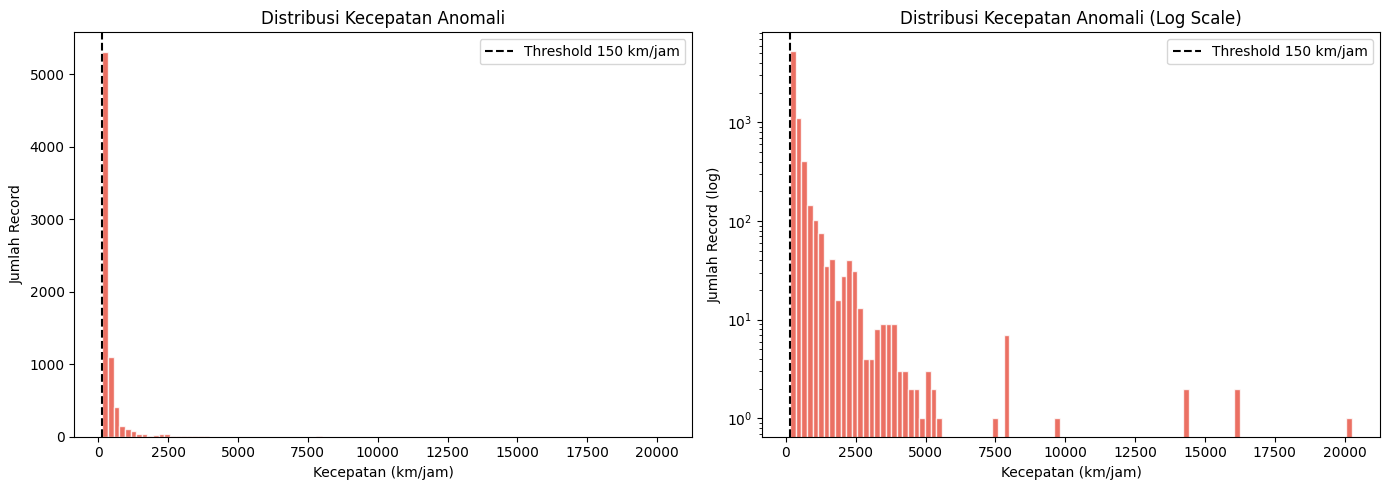

In [19]:
# Distribusi kecepatan anomali
speed_data = con.execute(f"""
    SELECT speed_kmph FROM read_parquet('{SPEED_ANOMALY_FILE}')
    WHERE speed_kmph <= 100000
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(speed_data['speed_kmph'], bins=100, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Kecepatan (km/jam)')
axes[0].set_ylabel('Jumlah Record')
axes[0].set_title('Distribusi Kecepatan Anomali')
axes[0].axvline(SPEED_THRESHOLD_KMPH, color='black', linestyle='--', label=f'Threshold {SPEED_THRESHOLD_KMPH} km/jam')
axes[0].legend()

axes[1].hist(speed_data['speed_kmph'], bins=100, color='#e74c3c', alpha=0.8, edgecolor='white', log=True)
axes[1].set_xlabel('Kecepatan (km/jam)')
axes[1].set_ylabel('Jumlah Record (log)')
axes[1].set_title('Distribusi Kecepatan Anomali (Log Scale)')
axes[1].axvline(SPEED_THRESHOLD_KMPH, color='black', linestyle='--', label=f'Threshold {SPEED_THRESHOLD_KMPH} km/jam')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'speed_anomaly_distribution.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

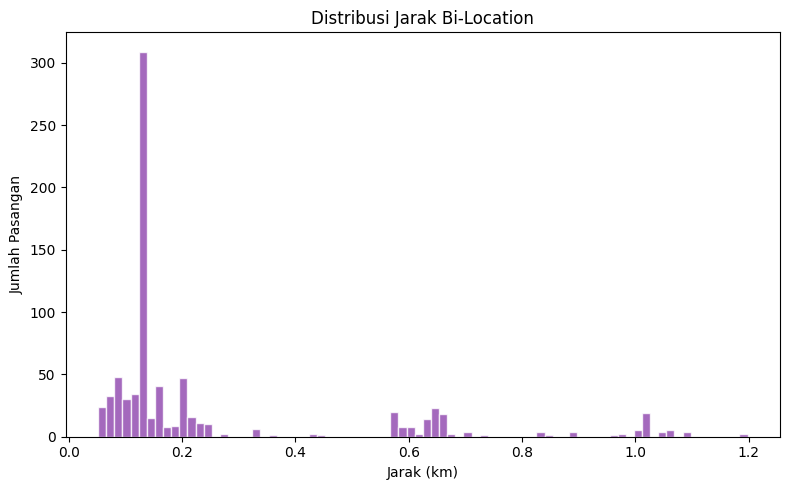

In [20]:
# Distribusi jarak bi-location
biloc_data = con.execute(f"""
    SELECT distance_m/1000 AS dist_km FROM read_parquet('{BILOC_ANOMALY_FILE}')
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(biloc_data['dist_km'], bins=80, color='#8e44ad', alpha=0.8, edgecolor='white')
ax.set_xlabel('Jarak (km)')
ax.set_ylabel('Jumlah Pasangan')
ax.set_title('Distribusi Jarak Bi-Location')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bilocation_distance_distribution.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Top MAID & Breakdown

In [21]:
# Top MAID kecepatan
top_speed = con.execute(f"""
    SELECT maid, COUNT(*) AS cnt, MAX(speed_kmph) AS max_speed, AVG(speed_kmph) AS avg_speed
    FROM read_parquet('{SPEED_ANOMALY_FILE}')
    GROUP BY maid ORDER BY cnt DESC LIMIT 20
""").df()
print("Top 20 MAID — Anomali Kecepatan:")
print(top_speed.to_string(index=False))

Top 20 MAID — Anomali Kecepatan:
                                maid  cnt   max_speed  avg_speed
8516b4c0-d7df-4f73-ad5a-f21039f32d0c  480 5041.832796 851.084777
27683c4b-5c14-4a14-9788-9aba0a7b0b38  302 4998.958444 773.808929
dfe1c884-187c-4269-91ad-cd43c503a814  105  902.124426 290.358877
4213fc32-db1f-4322-be8e-e4230784254d   78 5138.167064 610.584691
8d007b7f-8b19-40b3-8dc7-1899911fa6db   59 4220.202428 637.727571
f9b98635-dc5b-41a8-14f4-8781d4cbb635   50 4640.712544 455.417036
e7c60198-fba7-4f75-b183-00885b8d541f   49  685.578573 298.326591
d60784a3-f519-447b-b90d-fb66c49921b6   45  458.949306 247.289762
9a2ac25e-904b-456f-8295-212638b9efce   39 1936.013625 374.799500
0cf521ba-ef54-497f-ae5e-e4e98bbaaf8c   38 1084.746933 331.269897
5afe0024-44d8-458a-9e6f-313a9a21f563   38 1306.667398 499.635452
176de385-971d-40dc-b2a8-92dc9707d8dd   37 1108.474463 297.300809
e7ceffe2-f508-4c36-adeb-11d77c362dfd   34  481.928711 199.764856
cb5d569a-ca04-45f6-105d-8445b35699b1   32  639.444005 264

In [22]:
# Top MAID bi-location
top_biloc = con.execute(f"""
    SELECT maid, COUNT(*) AS pairs, MAX(distance_m)/1000 AS max_dist_km
    FROM read_parquet('{BILOC_ANOMALY_FILE}')
    GROUP BY maid ORDER BY pairs DESC LIMIT 20
""").df()
print("Top 20 MAID — Anomali Bi-Location:")
print(top_biloc.to_string(index=False))

Top 20 MAID — Anomali Bi-Location:
                                maid  pairs  max_dist_km
8516b4c0-d7df-4f73-ad5a-f21039f32d0c    344     1.096172
27683c4b-5c14-4a14-9788-9aba0a7b0b38    232     0.727313
4213fc32-db1f-4322-be8e-e4230784254d     91     0.672977
02588800-1a97-487d-8b62-8ff4b58bc86d     16     0.088063
b105e8ec-d6a6-4b96-92d7-372890fe7f37     15     0.212078
99b25658-998a-40d2-ac94-b65f1b0b515a     11     0.082523
0d21360c-6686-4e55-bdc9-7f64e5996255     10     0.057974
baf81eb6-8461-42dd-915c-4bb592160e6f      7     0.217063
65bb3fed-4462-4854-b128-7aa8918746bb      6     0.093478
94f58f82-6df6-4ad7-9d46-b4c06d26f2dd      6     0.101095
658fe1d8-b231-400f-a94d-1189cb5f8297      5     0.577198
b3b2d261-45db-470d-8f16-68ceafb9e298      4     0.703681
b12dc0fa-bc45-46e2-aed8-988807f7a3de      4     1.197862
c4d11247-dd2a-4b35-818d-71be46014ada      3     0.066289
afe5ea6c-d117-4450-a8fb-5dbab7725b85      3     0.234648
411199a3-3190-46bb-964c-50e0d45f44ef      3     0.269

In [23]:
# Breakdown per kategori kecepatan
tiers = con.execute(f"""
    SELECT
        CASE
            WHEN speed_kmph < 300 THEN '150-300 km/jam'
            WHEN speed_kmph < 500 THEN '300-500 km/jam'
            WHEN speed_kmph < 1000 THEN '500-1000 km/jam'
            WHEN speed_kmph < 10000 THEN '1k-10k km/jam'
            ELSE '>10k km/jam'
        END AS kategori,
        COUNT(*) AS jumlah
    FROM read_parquet('{SPEED_ANOMALY_FILE}')
    GROUP BY kategori ORDER BY MIN(speed_kmph)
""").df()
print("Breakdown per Kategori:")
print(tiers.to_string(index=False))

Breakdown per Kategori:
       kategori  jumlah
 150-300 km/jam    4783
 300-500 km/jam    1472
500-1000 km/jam     735
  1k-10k km/jam     426
    >10k km/jam       5


## Ringkasan

In [ ]:
## Hapus MAID Bermasalah

# Hapus semua baris yang MAID-nya terlibat dalam anomali kecepatan atau bi-location
CLEANED_FILE = os.path.join(OUTPUT_DIR, "gps_ring_road_utara_cleaned.parquet")

# Kumpulkan semua MAID bermasalah
speed_maids_list = con.execute(f"SELECT DISTINCT maid FROM read_parquet('{SPEED_ANOMALY_FILE}')").fetchall()
biloc_maids_list = con.execute(f"SELECT DISTINCT maid FROM read_parquet('{BILOC_ANOMALY_FILE}')").fetchall()

problem_maids = set([m[0] for m in speed_maids_list] + [m[0] for m in biloc_maids_list])
print(f"👤 Total MAID bermasalah: {len(problem_maids):,}")

# Buat filter string untuk SQL IN clause
maid_in = ", ".join([f"'{m}'" for m in problem_maids])

t0 = time.time()
con.execute(f"""
    COPY (
        SELECT * FROM read_parquet('{INPUT_FILE}')
        WHERE maid NOT IN ({maid_in})
    )
    TO '{CLEANED_FILE}'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""")

elapsed = time.time() - t0
cleaned_rows = con.execute(f"SELECT COUNT(*) FROM read_parquet('{CLEANED_FILE}')").fetchone()[0]
print(f"✅ Selesai dalam {elapsed:.1f} detik")
print(f"📊 Baris tersisa: {cleaned_rows:,} (dari {total_rows:,})")
print(f"📁 {CLEANED_FILE}")